# Trabajo Práctico 2

UdeMM - Ingeniería en Sistemas

Simulación de Modelos en Derivadas Parciales

## Grilla de cálculo (stencil)

### Consigna
Asocie cada uno de los siguientes _stencils_ a su correspondiente esquema de cálculo.

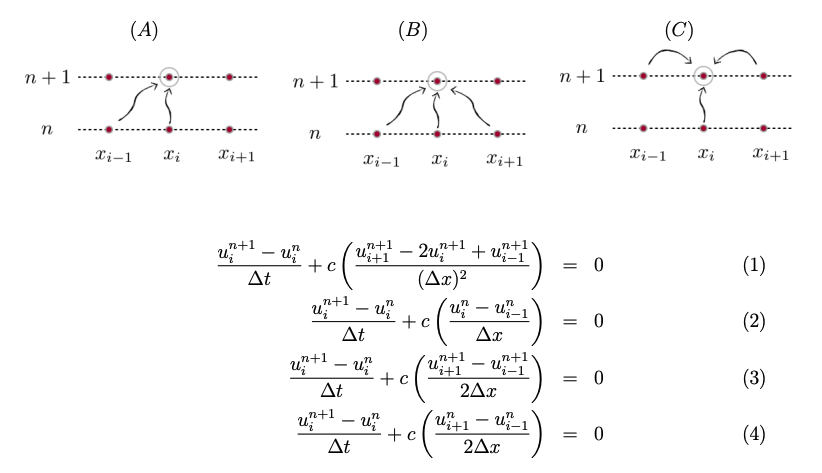

### Respuesta
El _stencil_ A corresponde a la expresión $2$.
Puesto que los términos que multiplican a la velocidad $c$ son $u_i^n$ y $u_{i-1}^n$.
Tal y como muestra el _stencil_ A.

El _stencil_ B, por su parte, se corresponde con la expresión 4.
Elección que justifica en la presencia de los términos  $u_i^n$,
$u_{i+1}^n$ y $u_{i-1}^n$, 
que coinciden con los mostrados en la grilla de cálculo.

Por último, la grilla de cálculo C, por los términos $u_{i-1}^{n+1}$,
$u_{i}^{n}$ y $u_{i+1}^{n+1}$, se corresponde con la expresión 3.

## Solución numérica

### Estabilidad

#### Consigna

Se considera un esquema de adelanto en tiempo y atraso en espacio para
discretizar un problema de advección lineal con un coeficiente
convectivo $c=4$ y un tamaño de paso espacial $\Delta x=2$. 
Determine el valor máximo del paso de tiempo $\Delta t$
que permita asegurar la estabilidad de la solución.

#### Respuesta

La estabilidad del esquema de discretización depende de la condición:

$$
\sigma = \frac{c \Delta t}{\Delta x} \leq 1
$$

Como $c=4$ y $\Delta x=2$:

$$
\frac{4 \Delta t}{2} \leq 1
$$
$$
\Delta t \leq \frac{1}{2}
$$

Por lo tanto, concluímos que, 
para asegurar la estabilidad de la solución,
se debe cumplir la condición $\Delta t \leq \frac{1}{2}$.

### SymPy

#### Consigna

Empleando `SymPy` evalúe la derivada parcial con respecto a $x$ 
de la expresión siguiente en $x=2.2$:

$$
\frac{\cos^2(x)\sin^3(x)}{4x^5\exp(x)}
$$

#### Respuesta

Primero importamos las librerías que vamos a emplear.

In [1]:
import numpy as np
from sympy import symbols, cos, sin, exp, init_printing, diff, nsolve
import matplotlib.pyplot as pl

Especificamos la salida en formato $\LaTeX$:

In [2]:
init_printing(use_unicode=True)

Fijamos `x` como variable simbólica para la función:

In [3]:
x = symbols('x')
x

Planteamos la expresión en `f`:

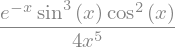

In [4]:
f = (cos(x)**2*sin(x)**3)/(4*x**5)/(exp(x))
f

Evaluamos la derivada:

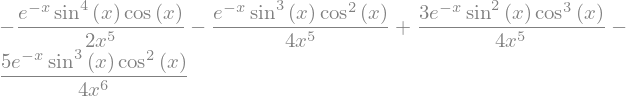

In [5]:
fprime = f.diff(x)
fprime

Y por último la evaluamos en $x=2.2$:

In [6]:
x22 = nsolve(fprime, x, 2.2)
x22

## Trabajo de código: Flujo de tráfico

### Respuesta

Para discretizar la ecuación de advección no lineal 
de la densidad del tráfico 
$\frac{\partial \rho}{\partial t} + \frac{\partial F}{\partial x} = 0$ 
usamos un esquema _forward_ en tiempo, _backward_ en espacio,
resultando en:

$$
\frac{\rho_{i}^{n + 1} - \rho_i^n}{\Delta t} 
+ \frac{F_i^n - F_{i-1}^n}{\Delta x}
= 0
$$

Por lo tanto, si despejamos $\rho_i^{n+1}$:

$$
\rho_i^{n+1} = \rho_i^n - \frac{\Delta t}{\Delta x} (F_i^n - F_{i-1}^n)
$$

In [7]:
v_max = 80
nx = 51
L = 11
dx = L / (nx - 1)
rho_max = 250
dt = .001

La condición inicial:

In [8]:
x = np.linspace(0, L, nx)
rho0 = np.ones(nx)*10
rho0[10:20] = 50
rho0

array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 50., 50., 50.,
       50., 50., 50., 50., 50., 50., 50., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.])